# Large Language Models - Assignment 1
## KNN Classification from Scratch

**Task 1:** Binary classification using KNN on the breast cancer dataset.

**Task 2:** Multi-class classification using KNN on CIFAR-10.

**Note:** KNN is implemented from scratch. No sklearn KNN/model is used.

## Task 1 - Binary Classification

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

### 1. Load the dataset

In [6]:
data = pd.read_csv('data.csv')

print('Dataset shape:', data.shape)
data.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### 2. Prepare the data

M = 1 (Malignant)

B = 0 (Benign)

In [7]:
# Remove spaces from column names
data.columns = data.columns.str.strip()

# Show column names
print("Columns in dataset:")
print(data.columns.tolist())

# Find the Diagnosis column
diagnosis_column = None

for column in data.columns:
    if column.lower() == "diagnosis":
        diagnosis_column = column
        break

print("\nDiagnosis column:", diagnosis_column)

# Convert M/B into 1/0
data[diagnosis_column] = data[diagnosis_column].map({
    "M": 1,
    "B": 0
})

# Remove unnecessary columns
if "id" in data.columns:
    data = data.drop("id", axis=1)

if "Unnamed: 32" in data.columns:
    data = data.drop("Unnamed: 32", axis=1)

# Separate features and target
X = data.drop(diagnosis_column, axis=1).values
y = data[diagnosis_column].values

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Columns in dataset:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Diagnosis column: diagnosis

Features shape: (569, 30)
Target shape: (569,)


### 3. Split the data into 80% training and 20% testing

In [8]:
np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 455
Testing samples: 114


### 4. Standardize the features

In [9]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

std[std == 0] = 1

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

## 5. Distance Functions

In [10]:
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def manhattan(a, b):
    return np.sum(np.abs(a - b))


def minkowski(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)


def cosine(a, b):
    denominator = np.linalg.norm(a) * np.linalg.norm(b)

    if denominator == 0:
        return 1

    similarity = np.dot(a, b) / denominator
    return 1 - similarity


def hamming(a, b):
    return np.mean(a != b)

## 6. KNN Classifier from Scratch

In [11]:
def knn_predict(X_train, y_train, X_test, k, distance_function):
    predictions = []

    for test_point in X_test:
        distances = []

        for i in range(len(X_train)):
            d = distance_function(test_point, X_train[i])
            distances.append((d, y_train[i]))

        distances.sort(key=lambda x: x[0])

        nearest = distances[:k]
        labels = [x[1] for x in nearest]

        prediction = Counter(labels).most_common(1)[0][0]
        predictions.append(prediction)

    return np.array(predictions)

## 7. Accuracy Function

In [12]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

## 8. Experiment with K values and distance metrics

In [13]:
K_values = [3, 4, 9, 20, 47]

distances = {
    'Euclidean': euclidean,
    'Manhattan': manhattan,
    'Minkowski': minkowski,
    'Cosine': cosine,
    'Hamming': hamming
}

results = {}

for name, function in distances.items():
    results[name] = []

    for k in K_values:
        prediction = knn_predict(
            X_train,
            y_train,
            X_test,
            k,
            function
        )

        acc = accuracy(y_test, prediction)
        results[name].append(acc)

        print(name, 'K =', k, 'Accuracy =', round(acc, 4))

Euclidean K = 3 Accuracy = 0.9474
Euclidean K = 4 Accuracy = 0.9561
Euclidean K = 9 Accuracy = 0.9298
Euclidean K = 20 Accuracy = 0.9386
Euclidean K = 47 Accuracy = 0.9386
Manhattan K = 3 Accuracy = 0.9649
Manhattan K = 4 Accuracy = 0.9649
Manhattan K = 9 Accuracy = 0.9474
Manhattan K = 20 Accuracy = 0.9386
Manhattan K = 47 Accuracy = 0.9386
Minkowski K = 3 Accuracy = 0.9474
Minkowski K = 4 Accuracy = 0.9474
Minkowski K = 9 Accuracy = 0.9298
Minkowski K = 20 Accuracy = 0.9386
Minkowski K = 47 Accuracy = 0.9386
Cosine K = 3 Accuracy = 0.9649
Cosine K = 4 Accuracy = 0.9561
Cosine K = 9 Accuracy = 0.9474
Cosine K = 20 Accuracy = 0.9561
Cosine K = 47 Accuracy = 0.9561
Hamming K = 3 Accuracy = 0.6842
Hamming K = 4 Accuracy = 0.6754
Hamming K = 9 Accuracy = 0.6579
Hamming K = 20 Accuracy = 0.6754
Hamming K = 47 Accuracy = 0.5877


## 9. Plot K vs Accuracy

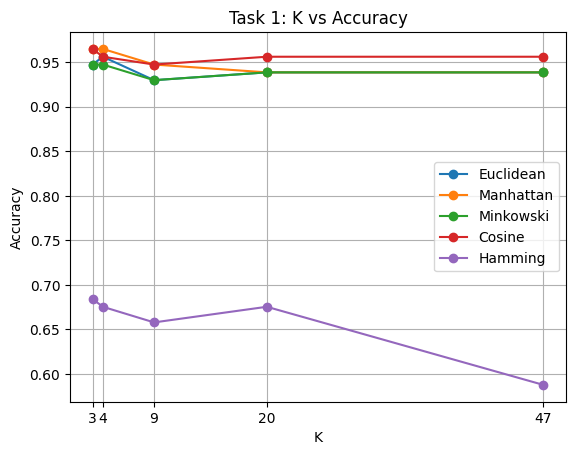

In [14]:
for name in results:
    plt.plot(K_values, results[name], marker='o', label=name)

plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Task 1: K vs Accuracy')
plt.xticks(K_values)
plt.legend()
plt.grid()
plt.show()

## 10. Find the best K and distance metric

In [15]:
best_accuracy = 0
best_k = 0
best_distance = ''

for name in results:
    for i in range(len(K_values)):
        if results[name][i] > best_accuracy:
            best_accuracy = results[name][i]
            best_k = K_values[i]
            best_distance = name

print('Best K:', best_k)
print('Best Distance:', best_distance)
print('Best Accuracy:', best_accuracy)

Best K: 3
Best Distance: Manhattan
Best Accuracy: 0.9649122807017544


## 11. Confusion Matrix, Precision and Recall

In [16]:
best_prediction = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k,
    distances[best_distance]
)

cm = np.zeros((2, 2), dtype=int)

for actual, predicted in zip(y_test, best_prediction):
    cm[actual][predicted] += 1

print('Confusion Matrix:')
print(cm)

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

precision = TP / (TP + FP)
recall = TP / (TP + FN)

print('\nPrecision:', precision)
print('Recall:', recall)

Confusion Matrix:
[[67  0]
 [ 4 43]]

Precision: 1.0
Recall: 0.9148936170212766


## BONUS

In [17]:
# Use two features for visualization
# radius_mean and texture_mean

X_train_2d = X_train[:, [0, 1]]
X_test_2d = X_test[:, [0, 1]]

print("Using features:")
print(data.columns[[0, 1]].tolist())

Using features:
['diagnosis', 'radius_mean']


In [18]:
# Train best KNN model using the two selected features

best_model_2d = KNNFromScratch if False else None

In [19]:
# Create a grid covering the feature space

x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1

y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

grid = np.c_[xx.ravel(), yy.ravel()]

print("Grid created:", grid.shape)

Grid created: (7031, 2)


In [20]:
# Predict the class of every point in the grid

grid_predictions = knn_predict(
    X_train_2d,
    y_train,
    grid,
    best_k,
    distances[best_distance]
)

grid_predictions = grid_predictions.reshape(xx.shape)

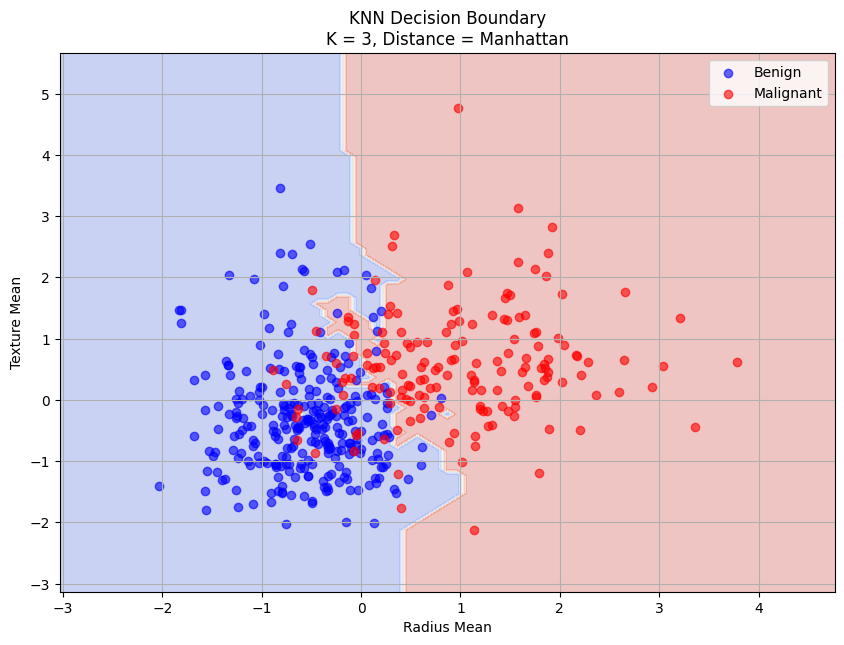

In [21]:
plt.figure(figsize=(10, 7))

# Decision regions
plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.3,
    cmap="coolwarm"
)

# Benign points
plt.scatter(
    X_train_2d[y_train == 0, 0],
    X_train_2d[y_train == 0, 1],
    color="blue",
    label="Benign",
    alpha=0.6
)

# Malignant points
plt.scatter(
    X_train_2d[y_train == 1, 0],
    X_train_2d[y_train == 1, 1],
    color="red",
    label="Malignant",
    alpha=0.6
)

# Correct feature names
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")

plt.title(
    "KNN Decision Boundary\n"
    + "K = " + str(best_k)
    + ", Distance = " + best_distance
)

plt.legend()
plt.grid()
plt.show()

### Task 1 Observation

The best K and distance metric are selected based on testing accuracy. Different K values produce different accuracies because K controls how many neighboring points participate in the classification. Different distance metrics also produce different results because they measure similarity differently.

# Task 2 - CIFAR-10 Multi-Class Classification

CIFAR-10 contains 50,000 training images and 10,000 test images.

Since KNN from scratch compares every test image with training images, using the complete dataset is very slow. For this lab experiment, a smaller subset is used.

In [22]:
import pickle
import os

## 12. Load CIFAR-10

In [23]:
!tar -xzvf cifar-10-python.tar.gz

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [24]:
def load_batch(filename):
    with open(filename, 'rb') as file:
        batch = pickle.load(file, encoding='bytes')

    X = batch[b'data']
    y = np.array(batch[b'labels'])

    return X, y

In [25]:
X_train_cifar = []
y_train_cifar = []

for i in range(1, 6):
    X, y = load_batch(
        'cifar-10-batches-py/data_batch_' + str(i)
    )

    X_train_cifar.append(X)
    y_train_cifar.append(y)

X_train_cifar = np.concatenate(X_train_cifar)
y_train_cifar = np.concatenate(y_train_cifar)

X_test_cifar, y_test_cifar = load_batch(
    'cifar-10-batches-py/test_batch'
)

print('Full training data:', X_train_cifar.shape)
print('Full testing data:', X_test_cifar.shape)

Full training data: (50000, 3072)
Full testing data: (10000, 3072)


## 13. Select a smaller subset

We use 5,000 training images and 1,000 testing images so that the from-scratch KNN can finish in a reasonable amount of time.

In [26]:
X_train_cifar = X_train_cifar[:5000]
y_train_cifar = y_train_cifar[:5000]

X_test_cifar = X_test_cifar[:1000]
y_test_cifar = y_test_cifar[:1000]

print('Training data:', X_train_cifar.shape)
print('Testing data:', X_test_cifar.shape)

Training data: (5000, 3072)
Testing data: (1000, 3072)


## 14. Normalize pixel values

In [27]:
X_train_cifar = X_train_cifar.astype(float) / 255.0
X_test_cifar = X_test_cifar.astype(float) / 255.0

## 15. Run KNN for CIFAR-10

In [28]:
results_cifar = {}

for name, function in distances.items():
    results_cifar[name] = []

    for k in K_values:
        prediction = knn_predict(
            X_train_cifar,
            y_train_cifar,
            X_test_cifar,
            k,
            function
        )

        acc = accuracy(y_test_cifar, prediction)
        results_cifar[name].append(acc)

        print(name, 'K =', k, 'Accuracy =', round(acc, 4))

Euclidean K = 3 Accuracy = 0.282
Euclidean K = 4 Accuracy = 0.284
Euclidean K = 9 Accuracy = 0.284
Euclidean K = 20 Accuracy = 0.272
Euclidean K = 47 Accuracy = 0.258
Manhattan K = 3 Accuracy = 0.303
Manhattan K = 4 Accuracy = 0.309
Manhattan K = 9 Accuracy = 0.324
Manhattan K = 20 Accuracy = 0.307
Manhattan K = 47 Accuracy = 0.296
Minkowski K = 3 Accuracy = 0.237
Minkowski K = 4 Accuracy = 0.237
Minkowski K = 9 Accuracy = 0.259
Minkowski K = 20 Accuracy = 0.25
Minkowski K = 47 Accuracy = 0.226
Cosine K = 3 Accuracy = 0.302
Cosine K = 4 Accuracy = 0.304
Cosine K = 9 Accuracy = 0.305
Cosine K = 20 Accuracy = 0.293
Cosine K = 47 Accuracy = 0.276
Hamming K = 3 Accuracy = 0.232
Hamming K = 4 Accuracy = 0.252
Hamming K = 9 Accuracy = 0.251
Hamming K = 20 Accuracy = 0.255
Hamming K = 47 Accuracy = 0.267


## 16. Plot CIFAR-10 K vs Accuracy

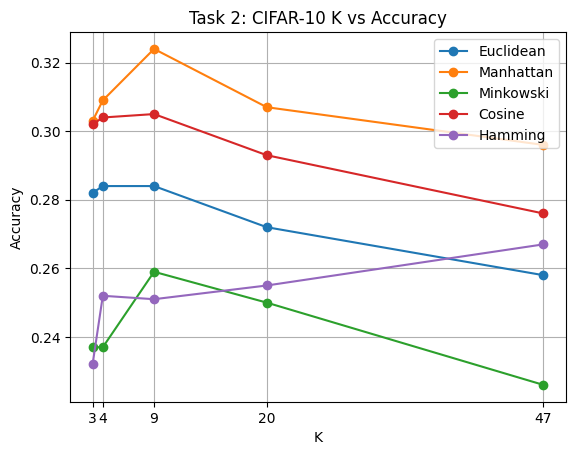

In [29]:
for name in results_cifar:
    plt.plot(
        K_values,
        results_cifar[name],
        marker='o',
        label=name
    )

plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Task 2: CIFAR-10 K vs Accuracy')
plt.xticks(K_values)
plt.legend()
plt.grid()
plt.show()

## 17. Find the best CIFAR-10 model

In [30]:
best_accuracy_cifar = 0
best_k_cifar = 0
best_distance_cifar = ''

for name in results_cifar:
    for i in range(len(K_values)):
        if results_cifar[name][i] > best_accuracy_cifar:
            best_accuracy_cifar = results_cifar[name][i]
            best_k_cifar = K_values[i]
            best_distance_cifar = name

print('Best K:', best_k_cifar)
print('Best Distance:', best_distance_cifar)
print('Best Accuracy:', best_accuracy_cifar)

Best K: 9
Best Distance: Manhattan
Best Accuracy: 0.324


## 18. Confusion Matrix for CIFAR-10

In [31]:
best_prediction_cifar = knn_predict(
    X_train_cifar,
    y_train_cifar,
    X_test_cifar,
    best_k_cifar,
    distances[best_distance_cifar]
)

cm_cifar = np.zeros((10, 10), dtype=int)

for actual, predicted in zip(y_test_cifar, best_prediction_cifar):
    cm_cifar[actual][predicted] += 1

print('CIFAR-10 Confusion Matrix:')
print(cm_cifar)

CIFAR-10 Confusion Matrix:
[[47  0 12  1  9  1  6  1 24  2]
 [ 9 10  9  4 16  1 12  0 24  4]
 [15  0 49  1 19  4  6  1  5  0]
 [ 7  1 19 17 25  9 19  1  5  0]
 [ 6  1 18  5 41  1  8  1  8  1]
 [ 6  0 18  8 21 12 11  6  4  0]
 [ 2  0 27  6 42  3 27  2  2  1]
 [ 5  0 20  4 27  4 11 20  9  2]
 [14  0  2  1  8  2  2  1 74  2]
 [10  0 11  3 12  2 11  5 28 27]]


## 19. Precision and Recall for CIFAR-10

In [32]:
precisions = []
recalls = []

for i in range(10):
    TP = cm_cifar[i][i]
    FP = np.sum(cm_cifar[:, i]) - TP
    FN = np.sum(cm_cifar[i, :]) - TP

    if TP + FP == 0:
        precision = 0
    else:
        precision = TP / (TP + FP)

    if TP + FN == 0:
        recall = 0
    else:
        recall = TP / (TP + FN)

    precisions.append(precision)
    recalls.append(recall)

print('Macro Precision:', np.mean(precisions))
print('Macro Recall:', np.mean(recalls))

Macro Precision: 0.4182617013898433
Macro Recall: 0.3201778702648751
